In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('dados_aula_01_exemplo_01.csv')

X = df[["age", "bmi", "children", "charges"]]


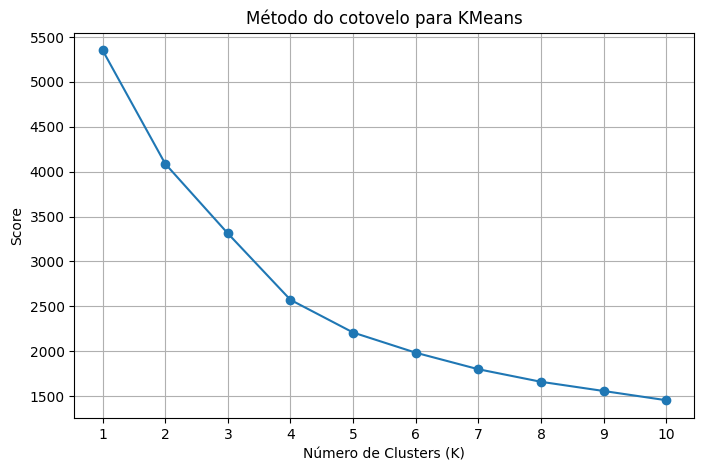

In [22]:
escalonador = StandardScaler()
imputador_numerico = SimpleImputer(strategy='median')

etapas_numericas = Pipeline([
    ('imputer', imputador_numerico),
    ('scaler', escalonador)
])

etapas_numericas 
x_transformado = etapas_numericas.fit_transform(X)

score = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(x_transformado)
    score.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))  
plt.plot(K_range, score, marker='o')
plt.title('Método do cotovelo para KMeans')   
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Score')
plt.xticks(K_range)
plt.grid(True)
plt.show()


In [25]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)   
kmeans.fit(x_transformado)

df['cluster'] = kmeans.labels_
df.head()

desc_age = df.groupby('cluster')['age'].describe()
print("age:")
print(desc_age) 

desc_imcs = df.groupby('cluster')['bmi'].describe()
print("\nbmi:")
print(desc_imcs)

desc_charges = df.groupby('cluster')['charges'].describe()
print("\ncharges:")
print(desc_charges)

age:
         count       mean        std   min   25%   50%   75%   max
cluster                                                           
0        408.0  52.514706   7.338082  36.0  47.0  53.0  58.0  64.0
1        165.0  39.872727  14.288902  18.0  27.0  41.0  52.0  64.0
2        346.0  39.939306  10.562680  18.0  31.0  40.0  48.0  64.0
3        419.0  25.381862   6.458351  18.0  19.0  24.0  31.0  41.0

bmi:
         count       mean       std     min     25%      50%       75%    max
cluster                                                                      
0        408.0  30.927292  6.024227  18.050  26.410  30.4000  35.21125  49.06
1        165.0  35.302879  4.315540  22.895  32.200  34.9600  37.07000  52.58
2        346.0  29.963382  6.057864  16.815  25.475  29.7175  33.60625  48.07
3        419.0  29.157482  5.896811  15.960  25.175  28.7850  33.00000  53.13

charges:
         count          mean          std          min           25%  \
cluster                              